# 003 - Local Indexing

Written by Jean-Baptiste Jacob

Last updated: 19/02/2026

Perform local indexing of orientation and unit cell pixel-by-pixel and map the results on a 2D grid (Pixelmap object). This notebook is for testing and tuning the indexing parameters, before running the script local_indexing.py in batch mode (notebook 003b).

### Load packages

In [88]:
import sys

# python environment stuff
IMAGED11_PATH = '/home/esrf/jean1994b'  # None means do not use git, otherwise enter the name of the folder to use for the git checkout "ImageD11" or "ImageD11_version_xx", etc
CHECKOUT_PATH = 'ImageD11'  # the name of the git checkout folder within path. None means guess


if IMAGED11_PATH is not None:
    if '/data/id11/nanoscope' not in sys.path:
        sys.path.append('/data/id11/nanoscope')
    import install_ImageD11_from_git
    install_ImageD11_from_git.setup_ImageD11_from_git(IMAGED11_PATH,CHECKOUT_PATH)

# Setting path via: 
sys.path.insert(0, /home/esrf/jean1994b/ImageD11 )
# Running from: /home/esrf/jean1994b/ImageD11/ImageD11/__init__.py


In [89]:
# general modules
import os, glob, time
import h5py
import matplotlib.pyplot as pl
import numpy as np
from tqdm import tqdm

# ImageD11 https://github.com/FABLE-3DXRD/ImageD11
import ImageD11.sinograms.dataset
import ImageD11.columnfile
import ImageD11.parameters
import ImageD11.indexing
import ImageD11.grain
import ImageD11.sym_u

# point-fit 3dxrd module available at https://github.com/jbjacob94/pf_3dxrd.   
from pf3dxrd.pf3dxrd import utils, friedel_pairs, pixelmap, crystal_structure, peak_mapping
from pf3dxrd.scripts import local_indexing

%load_ext autoreload
%autoreload 2
%matplotlib ipympl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load data
- filtered peakfile (saved from notebook 002_Phase_Labelling)
- 2D map (Pixelmap)$
- dataset object

In [143]:
def load_data(dset, parfile, pname):
    # paths
    pksfile = os.path.join(data_dir, dsname+'_pk2d_p_flt.h5')
    dsfile  =  os.path.join(data_dir, dsname+'_dataset.h5')
    xmapfile =  os.path.join(data_dir, dsname+'_xmap.h5')

    ds = ImageD11.sinograms.dataset.load(dsfile)
        
    # load pixelmap
    xmap = pixelmap.load_from_hdf5(xmapfile)
    print(xmap)
    # crystal structure we want to index
    cs = xmap.phases.get(pname)
    pid = cs.phase_id
    
    # load cf  + keep only peaks from the phase we want to index
    cf = ImageD11.columnfile.columnfile(pksfile)
    cf.parameters.loadparameters(parfile)
    friedel_pairs.update_geometry_fpairs(cf, ds)
    cf.filter(cf.phase_id==pid)
    utils.get_colf_size(cf)
    print(f'N peaks: {cf.nrows}')
    
    # add pixel labeling to cf + sort by pixel index
    if 'xyi' not in cf.titles:
        peak_mapping.add_pixel_labels(cf, ds = ImageD11.sinograms.dataset.load(dsfile))
    if not cf.sortedby == 'xyi':
        print('sorting peakfile by "xyi"...')
        cf.sortby('xyi')
    
    return xmap, cf, cs, ds


In [295]:
# paths
data_dir = '/home/esrf/jean1994b/test_datasets/SI3/'
#data_dir = '/home/esrf/jean1994b/test_datasets/C18A_01_z180/'

dsname = 'SI3_DT360Z5480'
#dsname = 'C18A_01_z180'

parfile= data_dir+'/SI3.par'
#parfile= data_dir+'/C18A_01.par'

# select phase to index. Thsi must be of course in the list of phases added in pixelmap
pname = 'oligoclase'

In [296]:
# load data
xmap, cf, cs, ds = load_data(dsname, parfile, pname)

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id', 'Npks', 'U', 'UBI', 'completeness', 'drlv2', 'indx_completeness', 'nindx', 'phase_label_confidence', 'uniqueness', 'unitcell'], 
 grains: 0
Reading your columnfile in hdf format
sorting peakfile by friedel pair index...
Total size =  103.02 MB
N peaks: 628046
sorting peakfile by "xyi"...


Note that crystal structures have been saved has phase attributes in the pixelmap HDF5 file at the end of Tutorial 002, so they don't need to be imported again from cif files. 

### Local indexing
Point-by-point $UBI$ fitting performed using the function `pixel_ubi_fit` from local_indexing.py. 

In [297]:
# initialize an Option obj which will be passed to the indexing function
OPTS = local_indexing.Options()
print(OPTS)

hkltol1: 0.05
hkltol2: 0.03
minpks: 10
maxpks: 5000
minpks_prop: 0.1
nrings: 10
max_mult: 12
px_kernel_size: 3
chunksize: 20
symmetry: cubic
unitcell: None
ncpu: 9


- **hkltol 1 + 2** –  tolerance parameter for indexing (1) and refinement (2), controlling the maximum mismatch (drlv) between a unit cell matrix candidate and reciprocal lattice vectors used for fitting. g-vectors outside this threshold are excluded.
- **minpks** – minimum number of peaks required to retain potential `UBI` candidates during indexing
- **minpks_prop** – minimum proportion of peaks (relative to the total peaks per pixel) required for a valid UBI candidate.  
  The value passed to the indexer is calculated as:  
  `max(minpks, len(gvecs) * minpks_prop)`  
- **maxpks** – max peak number cutoff for 1st-round indexing: to avoid lengthy calculation, 1st-stage indexing is performed on the N-strongest diffraction peaks (ordered by decreasing intensity), where `maxpks = Nmax`. 2nd-stage refinement then includes all peaks
- **nrings** – maximum number of hkl rings to test when searching for `UBI` candidates.  
- **max_mult** – maximum multiplicity of the hkl rings used to test potential `UBI` candidates.
- **px_kernel_size** – size of the pixel kernel used for peak selection. A value of `1` corresponds to single-pixel selection. `px_kernel_size = 3` takes a $3x3$ kernel around the central pixel
- **unitcell** – read directly from the crystal structure provided as input.
- **chunksize** – option for multiprocessing. List of pixels to index is splitted into chunks of specified length sent to different workers to speed up indexing.
- **ncpu** Number of cpu cores for parallelization. By default, uses all available workers. 
- **symmetry** – crystal symmetry, provided as an `ImageD11.sym_u` object. Must be one of: 'cubic', 'hexagonal', 'trigonal', 'rhombohedralP', 'trigonalP', 'tetragonal', 'orthorhombic', 'monoclinic_c', 'monoclinic_a', 'monoclinic_b', 'triclinic'
- **unitcell** – crystallographic unit cell of the phase being indexed. This is read from the crystal structure (cs) object. 


Update symmetry and unit cell for the phase to index, and any other parameter if needed

In [298]:
OPTS.setsymmetry('triclinic')
OPTS.unitcell = ImageD11.unitcell.unitcell( cs.cell , cs.lattice_type)
OPTS.hkltol1 = 0.12
OPTS.hkltol2 = 0.08
OPTS.maxpks = 800
OPTS.max_mult = 12
OPTS.nrings = 30

updated symmetry to triclinic. Symmetry group defined in self.sym.group


In [154]:
OPTS.setsymmetry('hexagonal')
OPTS.unitcell = ImageD11.unitcell.unitcell( cs.cell , cs.lattice_type)
OPTS.hkltol1 = 0.1
OPTS.hkltol2 = 0.08
OPTS.maxpks = 8000
OPTS.nrings = 12

updated symmetry to hexagonal. Symmetry group defined in self.sym.group


**NOTE**: For quartz (and some other phases in the trigonal and tetragonal group), the lattice symmetry is higher than the point group symmetry. For quartz, the hexagonal lattice has 60° (6-fold) symmetry but the crystazl structure only has 120° (3-fold) symmetry, so there are two possible ways to orient the trigonal cell inside that hexagonal "box", that are rotated by 60° (or 180°, it is equivalent in the hexagonal symmetry) about the c-axis. These mirror orientations form Dauphiné Twins, and they are ubiquitous in natural quartz, forming patchy domains within single crystals.

This causes problem for indexing in the point group symmetry, because the imageD11 indexer does not take into account peak intensities, which are needed to unambiguously resolve the crystal structure (some orientations are equivalent in the lattice symmetry group but not in the point group). Therefore, we must index first in the lattice symmetry. Then, another script is used to find the correct unit cell matrix using peak intensities.

In [299]:
print(OPTS)

hkltol1: 0.12
hkltol2: 0.08
minpks: 10
maxpks: 800
minpks_prop: 0.1
nrings: 30
max_mult: 12
px_kernel_size: 3
chunksize: 20
symmetry: triclinic
unitcell: Unitcell | [  8.154  12.823   7.139  94.06  116.5    88.59 ] | C
ncpu: 9


#### Prepare g-vectors for indexing
create a separate temporay file containing the g-vectors to index and save it. Then, multiple processes will be able to access these data at the same time. Optionally, it is possible to filter the g-vectors to index (e.g. filter by intensity to index only the strongest peaks). 


In [300]:
# save g-vectors to index in a temporary file
# g-vectors to index. take only useful columns with g-vector coordinates, peak intensities and pixel coordinates in the sample
to_index = ImageD11.columnfile.colfile_from_dict( { name: cf.getcolumn(name) for name in 'gx gy gz xyi norm_intensity'.split() } )

# optional : filter to remove some weak peaks
#to_index.filter(to_index.sum_intensity > 50)

# sort by pixel index and save
to_index.sortby('xyi')
utils.colf_to_hdf(to_index, 'to_index.h5', save_mode='full')

Select pixel indices `xyi_uniqs` to index. Using a small subset makes it much faster to index for fine-tuning input parameters. However, I would recommend to try indexing a full map before runnign the script in batch mode, to make sure there is no radial artifact resulting from inadapted tolerance parameters.

In [302]:
#list of pixels to index
# FULL MAP
xyi_uniqs = xmap.xyi[xmap.phase_id == cs.phase_id]

# RECTANGULAR SUBSET: uncomment these lines if you want to index only a subset of the map
sel = np.all([np.abs(xmap.xi-70) < 20, np.abs(xmap.yi - 57) < 20, xmap.phase_id == cs.phase_id], axis=0)
xyi_uniqs = xmap.xyi[sel]

print(f'Number of pixels to process: {len(xyi_uniqs)}')

Number of pixels to process: 704


**General recommendations for parameters tuning:**  
- Start with low values for `max_mult`, `nrings`, and `hkltol`, and set `px_kernel_size = 1` (single pixel selection).  
- If the output appears noisy, gradually increase `max_mult`, `nrings`, and `px_kernel size` until you obtain smoother results.  
- If the map appears incomplete, try relaxing the `minpks` and/or `hkltol` parameters slightly.
- Plot the map of average `drlv2` after indexing. If there is a radial increase in `drlv2` /radial decrease in `nindx` (typical for large samples >2-3mm), try to relax a bit hkltol_2 to retain more g-vectors from domains far away from the rotation center. There is a tradeoff here between precision (using more stringent hkltol to keep only the best matching g-vectors) and map consistency across a large radial domain


#### Test local indexing on one pixel
make sure indexing works correctly. Computation time should be in the range of 100ms to 1s. If it is much longer, this may be caused by inadapted format of the xyi array in the peakfile (should be native int type rather than numpy.int). 

In [303]:
# wrap arguments to pass to indexing function
px = xyi_uniqs[24]   # pixel to index
args = (px, OPTS)  # wrap arguments to pass to indexing function

In [304]:
# create a context for indexing: loads to_index, update pars, etc. and closes it when finished
with local_indexing.indexing_context(parfile, cs):
    t0 = time.perf_counter()
    res = local_indexing.pixel_ubi_fit(args)
    t = time.perf_counter() - t0
    print(f'results: {res}')
    print(f'time: {100*t:.4f} ms')

to_index loaded: 628046 rows, 23.96 MB

results: (380075, array([[-6.21976083,  0.70441046, -5.23580541],
       [ 7.91197993,  3.80555343, -9.36175204],
       [ 2.97321786, -6.47356847,  0.56765334]]), 176, 0.000398231096015278, 0.1819185969642228)
time: 207.0409 ms


output structure:  tuple `(px_index, UBI, nindx, drlv2_mean, indx_completeness)`:
- `px_index` is the 'xyi' index (`xyi = 10000.yi+xi`) corresponding to the indexed pixel
- `UBI` is the best match for the lattice vectors matrix
- `nindx` is the number of g-vectors used to refine the lattice vector matrix
- `drlv2_mean` is the average drlv2 value for all g-vectors retained for fitting.
- `indx_completeness` is the fraction of indexed intensity over total intensity $\frac{I_{indx}}{I_{tot}}$ 


#### Run local indexing in parallel
Now everything is set up, we can run indexing in parallel. Results are stored in a temporary dictionnary. Then we will unpack these results and update the pixelmap. 

In [305]:
# define argument list
argslist = [(px, OPTS) for px in xyi_uniqs]
OPTS.chunksize = 50
results = local_indexing.run_indexing_parallel(argslist, OPTS, parfile, cs)



Loading to_index.h5...
to_index loaded: 628046 rows, 23.96 MB

Local indexing...


pixels indexed: 100%|██████████| 704/704 [01:34<00:00,  7.46it/s]


#### Extract results and add them to pixelmap

Result shave been written in a dictionnary 'results', which needs to be unpacked. The function local_indexing.update_xmap takes the data from the result dictionnary and write them as new columns in the pixelmap. By default, update_xmap resets all pixels of the selected phase (overwrite = True). You can also choose not to touch previously indexed pixels, and write only data where nothing has been indexed (not recommended except for testing different indexing options). Pixels belonging to other phases will not be touched, so you do not risk to overwrite a previously indexed phase.

In [306]:
local_indexing.update_xmap(xmap, xyi_uniqs, results, pname, drlv2_max = 0.1, overwrite = True)

extracting results...
updating xmap...


/home/esrf/jean1994b/ImageD11/ImageD11/grain.py:142: RuntimeWarning: invalid value encountered in scalar divide
  al = np.degrees(np.arccos(G[1, 2] / b / c))
/home/esrf/jean1994b/ImageD11/ImageD11/grain.py:143: RuntimeWarning: invalid value encountered in scalar divide
  be = np.degrees(np.arccos(G[0, 2] / a / c))
/home/esrf/jean1994b/ImageD11/ImageD11/grain.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ga = np.degrees(np.arccos(G[0, 1] / a / b))
/home/esrf/jean1994b/pf3dxrd/pf3dxrd/pixelmap.py:427: RuntimeWarning: invalid value encountered in cast
  dat[pxindx] = newvals.astype(dat.dtype)


In [307]:
print(xmap)

Pixelmap:
 size: (110, 110),
 phases: ['notIndexed', 'quartz', 'magnetite', 'biotite', 'orthoclase', 'oligoclase'],
 phase_ids: [-1, 0, 1, 2, 3, 4],
 titles: ['xyi', 'xi', 'yi', 'phase_id', 'grain_id', 'Npks', 'U', 'UBI', 'completeness', 'drlv2', 'indx_completeness', 'nindx', 'phase_label_confidence', 'uniqueness', 'unitcell'], 
 grains: 0


There are several new columns: 'nindx', 'drlv2', UBI', 'U', 'unitcell'. nindx and drlv2 are indexing statistics returned by the function score_and_refine from cImageD11. nindx is the number of peaks retained for the best-matching $UBI$. drlv2 is the deviation between computed hkl indices for a g-vector and the closest integer values: drlv2 =  (h-int(h))² + (k-int(k))² + (l-int(l))². The drlv2 value written in xmap is the mean drlv2 of all indexed peaks over each pixel. 'UBI' is the unit cell matrix (each column is a unit cell vector in real space). U is the crystal rotation matrix giving the grain orientation in sample reference frame. unitcell is a (6,1) array containing fitted unit cell parameters, computed from the B matrix. 

### Plot
make plots for orientation and indexing statistics

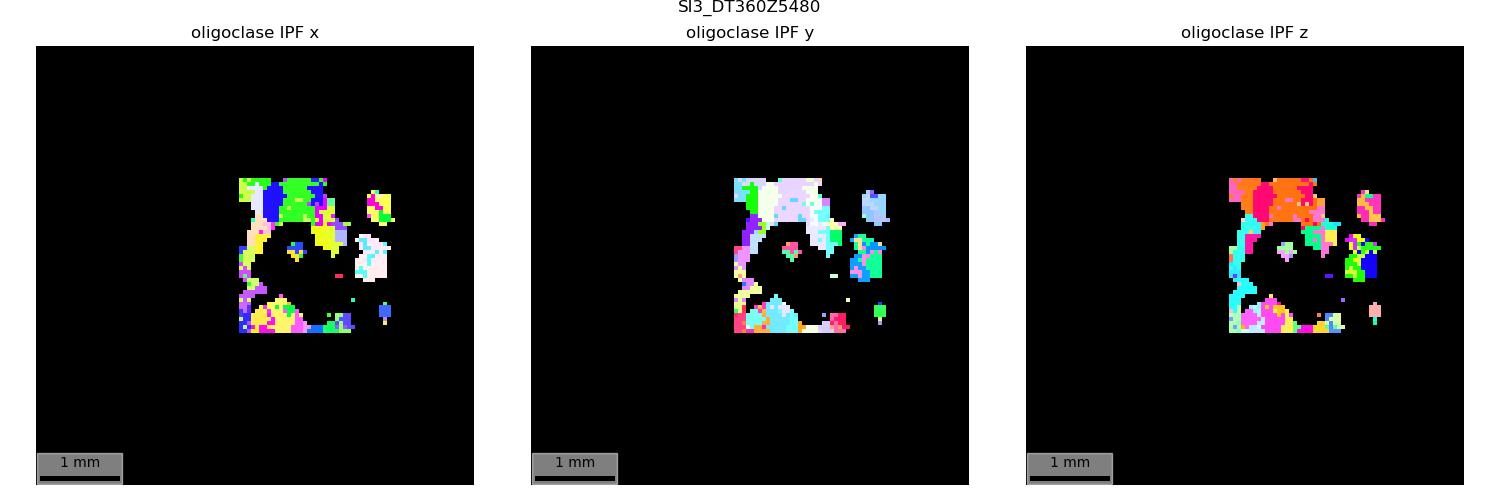

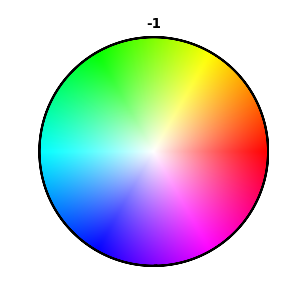

In [308]:
save=False
xmap.plot_ipf_orientation(phase=pname, datacolname='U', ipf_directions='xyz', save=save, hide_cbar=False, out=False)


In [ ]:
save=False
var_to_plot = ['nindx','drlv2', 'indx_completeness', 'Npks']
kw = {'cmap':'viridis'}

for var in var_to_plot:
    if var in xmap.titles():
        xmap.plot(var, phase=pname, autoscale=True, hist_tails_cut=[1,99], save=save)

### Noisy orientations investigation
In case the orientation map looks noisy, you may want to know whats going on with badly indexed pixels. It can be useful to look at g-vectors and how they are indexed
- select two pixels (one correctly oriented, one noisy orientation)
- run indexing on both with loginfo=True, to print info on ubis found and indexing scores

Typical issues:
- too few / bad g-vectors on noisy pixels -> try to increase kernel size to get more g-vectors from neighbors 
- maxpks or nrings too low: miss the "correct" orientation -> increase sliughtly these parameters until the correct orientation is found

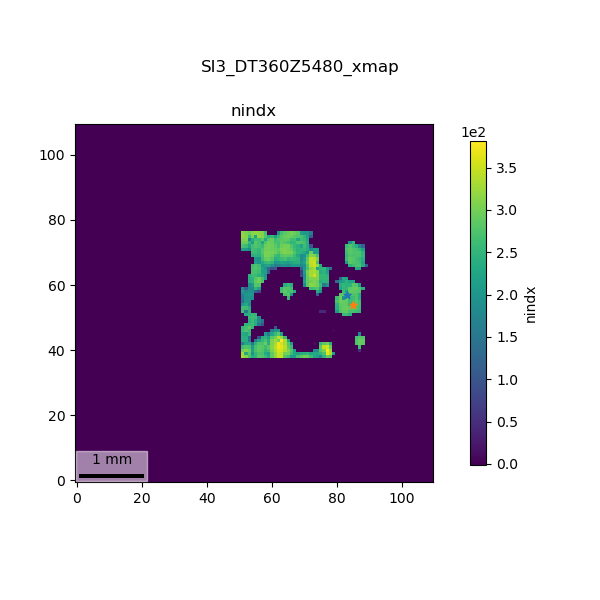

In [319]:
# select list of pixels to investigate. xyi index value: xyi = 1000.yi + xi  (e.g. (xi,yi) = (34,23) -> xyi = 230034
px1 = 570083
px2 = 540085


# plot them on the map to see where they are
kw = {'cmap':'viridis'}
fig = xmap.plot('nindx', phase=pname, out=True,**kw)
for px in [px1,px2]:
    fig.axes[0].scatter(px%10000,px//10000, s=30, marker='*')
fig.axes[0].set_axis_on()
    

In [320]:
#plot pole figures of g-vectors (aligned with crystallographic c-axis pointing upward)-> check if they correspond to a unique grain

import orix.quaternion as oq
import orix.vector as ovec

def get_gvecs(cf, px, kernel_size=1):
    # for pixels. px: index xyi = 1000*yi+xi
    s = peak_mapping.pks_from_px(cf.xyi, px, kernel_size=kernel_size)
    gv = np.array( (cf.gx[s],cf.gy[s],cf.gz[s])).T.copy()
    ints = cf.norm_intensity[s]
    return gv, ints, s

def plot_gvectors_polefig(cf, px, kernel_size=1, sf=1, **subplot_kw):
    fig = pl.figure(figsize=(5,5), layout='constrained')
    fig.suptitle(f'clustered g-vectors', fontsize=14, fontweight="bold")

    ax = fig.add_subplot(111, **subplot_kw)
    ax.set_axis_off()
    U = xmap.U[xmap.xyi == px]
    gv, ints, sel = get_gvecs(cf, px, kernel_size)
    R = oq.Rotation.from_matrix(U)  # realign g-vectors to have c-axis pointing upward
    
    V= ovec.Vector3d(gv).rotate(R.axis, -R.angle)
    ax.scatter(V, c=pow(ints,1/3), s=sf*pow(ints,1/3))
    ax.set_title(f'x={px%10000:d}, y={px//10000:d}')


In [321]:
for px in [px1,px2]:
    gv, ints, s = get_gvecs(cf, px, kernel_size=3)
    print(len(ints), ints.sum())

3266 10594464.9306736
2280 14319744.77230215


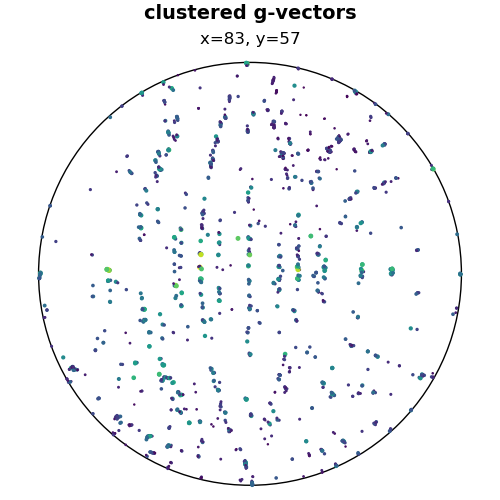

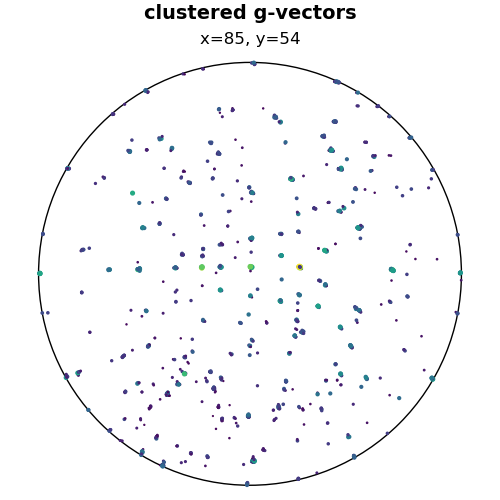

In [322]:
subplot_kw ={'projection':'stereographic','hemisphere':'upper'}
for px in [px1, px2]:
    plot_gvectors_polefig(cf, px, kernel_size=3, sf=.2, **subplot_kw)

In [327]:
OPTS.px_kernel_size = 3
OPTS.nrings = 40
OPTS.max_mult = 12
OPTS.maxpks = 2000
print(OPTS)

hkltol1: 0.12
hkltol2: 0.08
minpks: 10
maxpks: 2000
minpks_prop: 0.1
nrings: 40
max_mult: 12
px_kernel_size: 3
chunksize: 50
symmetry: triclinic
unitcell: Unitcell | [  8.154  12.823   7.139  94.06  116.5    88.59 ] | C
ncpu: 9


In [326]:
# index each pixel in debug mode, to see how ubi scores look like

with local_indexing.indexing_context(parfile, cs):
    for px in [px1, px2]:
        args = (px, OPTS)
        print(f'px : {px}')
        res = local_indexing.pixel_ubi_fit(args, loginfo=True)
        print(f'results: {res}')
        print(f'\n========================\n')

to_index loaded: 628046 rows, 23.96 MB

px : 570083
ngvecs: total:8490, selec:2000
UBI guesses:

[[ -0.82553142   7.3250909    3.50248731]
 [  1.23358171   5.84711073 -11.34954257]
 [ -6.03320273  -3.34011319  -1.84511158]]

[[  0.82524601  -7.37204413  -3.39220606]
 [ -1.73424997   4.68407673 -11.84514309]
 [  6.01754128   3.65241788   1.14943969]]

[[  0.8344471   -7.32336692  -3.50126132]
 [ -0.56484125   4.99891414 -11.815892  ]
 [  6.0350649    3.37799639   1.82837992]]

[[ -0.81915323   7.38145664   3.38794073]
 [ -0.17920279   5.54053493 -11.5812705 ]
 [ -6.02241416  -3.66800687  -1.13794075]]

ubi:
[[ -0.82297106   7.3269028    3.50226959]
 [  1.2487693    5.86056216 -11.34885038]
 [ -6.0357952   -3.34073536  -1.85067145]]
score:(2078, 0.0015157507688070854), 1370937.783944132

ubi:
[[  0.82029003  -7.3675014   -3.39611409]
 [ -1.7299511    4.71018002 -11.81673243]
 [  6.02341178   3.65020768   1.15439867]]
score:(1502, 0.0022203519191867265), 676469.341198018

ubi:
[[  0.83558

### Save indexed map and options
once you are satisfied with indexing outputs, save the results in a json file. If the map has been fully indexed, you can save it as well. Nothing has been added to the peakfile, so no need to save cf.

Re-do the process for every phase to index.

In [255]:
xmap.save_to_hdf5()

Pixelmap saved to: /home/esrf/jean1994b/test_datasets/SI3/SI3_DT360Z5480_xmap.h5


In [256]:
OPTS.save(os.path.join(data_dir,f"indexing_pars_{pname}.json"))

[SAVED] Options saved to /home/esrf/jean1994b/test_datasets/SI3/indexing_pars_orthoclase.json
